Import necessary libraries

In [927]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Load dataset

In [928]:
meps_data = pd.read_csv('Datasets/integrated_data.csv')
meps_data.head()

,Unnamed: 0,Person.ID,Drug,Quantity,Strength,Day_Supply,Daily_Frequency,Daily_Dosage,Year,Age,Sex,Ethnicity,Race,Personal_income,Family_income,Poverty_category,Can.t_get_PMED,Insurance_coverage,PMED_insurance_coverage,Concentration
0,1,40001101,desoximetasone,60.0,50000.0,30.000000,2.000000,100000.000000,2014,36.0,1.0,3.0,2.0,12000.0,68000.0,4.0,2.0,1.0,1.0,0.000805
1,2,40001101,desoximetasone,60.0,50000.0,30.000000,2.000000,100000.000000,2014,36.0,1.0,3.0,2.0,12000.0,68000.0,4.0,2.0,1.0,1.0,0.000805
2,3,41807102,desoximetasone,60.0,250000.0,25.777778,2.327586,581896.551724,2014,30.0,2.0,4.0,4.0,0.0,100000.0,5.0,2.0,1.0,1.0,0.004687
3,4,42214102,desoximetasone,100.0,250000.0,25.777778,3.879310,969827.586207,2014,61.0,2.0,2.0,1.0,66410.0,105604.0,5.0,2.0,2.0,2.0,0.007811
4,5,42214102,desoximetasone,100.0,250000.0,25.777778,3.879310,969827.586207,2014,61.0,2.0,2.0,1.0,66410.0,105604.0,5.0,2.0,2.0,2.0,0.007811


Analyse the columns in dataset

In [929]:
print(meps_data.columns)

Index(['Unnamed: 0', 'Person.ID', 'Drug', 'Quantity', 'Strength', 'Day_Supply',
       'Daily_Frequency', 'Daily_Dosage', 'Year', 'Age', 'Sex', 'Ethnicity',
       'Race', 'Personal_income', 'Family_income', 'Poverty_category',
       'Can.t_get_PMED', 'Insurance_coverage', 'PMED_insurance_coverage',
       'Concentration'],
      dtype='object')


Analyse the data type of each feature

In [930]:
print(meps_data.dtypes)

Unnamed: 0                   int64
Person.ID                    int64
Drug                        object
Quantity                   float64
Strength                   float64
Day_Supply                 float64
Daily_Frequency            float64
Daily_Dosage               float64
Year                         int64
Age                        float64
Sex                        float64
Ethnicity                  float64
Race                       float64
Personal_income            float64
Family_income              float64
Poverty_category           float64
Can.t_get_PMED             float64
Insurance_coverage         float64
PMED_insurance_coverage    float64
Concentration              float64
dtype: object


Drop unimportant columns

In [931]:
meps_data = meps_data.drop(['Unnamed: 0', 'Person.ID'], axis=1)

Handle infinite values

In [934]:
meps_data = meps_data[~meps_data.isin([np.inf, -np.inf]).any(axis=1)]

Handle missing values

In [935]:
missing_values = meps_data.isnull().sum()
print("Missing values in each column:")
print(missing_values[missing_values > 0])

Missing values in each column:
Strength                    21
Daily_Dosage                21
Age                        810
Sex                        810
Ethnicity                  810
Race                       810
Personal_income            810
Family_income              810
Poverty_category           810
Can.t_get_PMED             810
Insurance_coverage         810
PMED_insurance_coverage    810
Concentration               21
dtype: int64


In [936]:
meps_data = meps_data.fillna(meps_data.mean(numeric_only=True))  # Numeric columns
for col in meps_data.select_dtypes(include=['object']).columns:
    meps_data[col] = meps_data[col].fillna(meps_data[col].mode()[0])

Check missing values

In [937]:
missing_values = meps_data.isnull().sum()
print("Missing values in each column:")
print(missing_values[missing_values > 0])

Missing values in each column:
Series([], dtype: int64)


Only drug columns is categorical so encode it

In [938]:
encoder = LabelEncoder()
meps_data['Drug'] = encoder.fit_transform(meps_data['Drug'])
meps_data.head()

,Drug,Quantity,Strength,Day_Supply,Daily_Frequency,Daily_Dosage,Year,Age,Sex,Ethnicity,Race,Personal_income,Family_income,Poverty_category,Can.t_get_PMED,Insurance_coverage,PMED_insurance_coverage,Concentration
0,107,60.0,50000.0,30.000000,2.000000,100000.000000,2014,36.0,1.0,3.0,2.0,12000.0,68000.0,4.0,2.0,1.0,1.0,0.000805
1,107,60.0,50000.0,30.000000,2.000000,100000.000000,2014,36.0,1.0,3.0,2.0,12000.0,68000.0,4.0,2.0,1.0,1.0,0.000805
2,107,60.0,250000.0,25.777778,2.327586,581896.551724,2014,30.0,2.0,4.0,4.0,0.0,100000.0,5.0,2.0,1.0,1.0,0.004687
3,107,100.0,250000.0,25.777778,3.879310,969827.586207,2014,61.0,2.0,2.0,1.0,66410.0,105604.0,5.0,2.0,2.0,2.0,0.007811
4,107,100.0,250000.0,25.777778,3.879310,969827.586207,2014,61.0,2.0,2.0,1.0,66410.0,105604.0,5.0,2.0,2.0,2.0,0.007811


Sample the dataset for easy managing and experimenting

In [939]:
class_distribution = meps_data['Drug'].value_counts().reset_index()
class_distribution.columns = ['Drug', 'Count']

# Display the full table in Jupyter Notebook
from IPython.display import display
display(class_distribution)

class_distribution.to_csv("drug_class_distribution.csv", index=False)
print("Saved class distribution to drug_class_distribution.csv")

,Drug,Count
0,25,48128
1,235,42601
2,254,40813
3,228,39499
4,14,34379
...,...,...
418,57,1
419,365,1
420,290,1
421,249,1


Saved class distribution to drug_class_distribution.csv


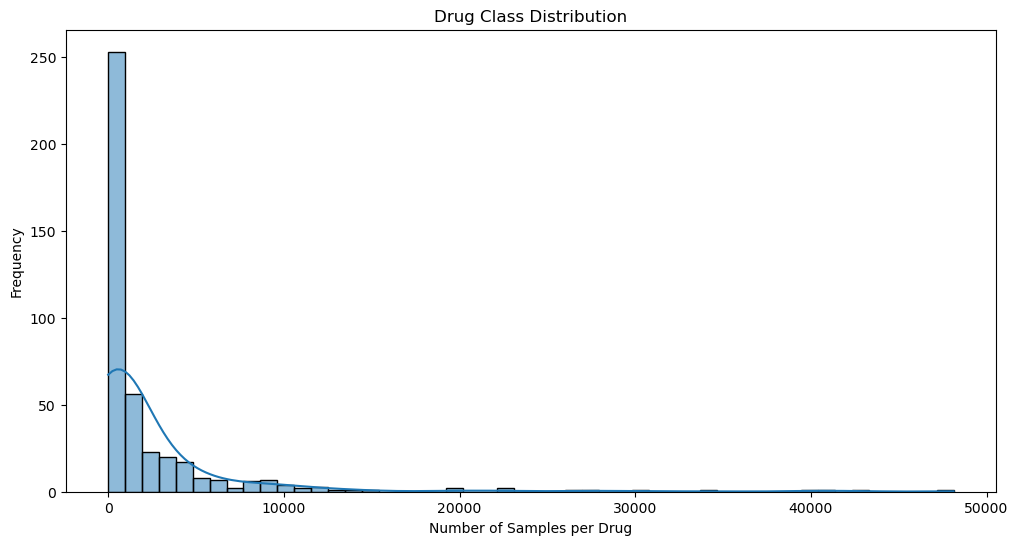

In [940]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot class distribution
plt.figure(figsize=(12, 6))
sns.histplot(meps_data['Drug'].value_counts(), bins=50, kde=True)
plt.xlabel("Number of Samples per Drug")
plt.ylabel("Frequency")
plt.title("Drug Class Distribution")
plt.show()


The dataset is highly imbalanced. Before sample its good to apply undersampling and smote to make it balanced

In [941]:
X = meps_data.drop(columns=['Drug'])  # Features
y = meps_data['Drug']  # Target variable

# Get class distribution
class_counts = y.value_counts()

# Set a minimum threshold (e.g., at least 500 samples per class)
min_samples_per_class = 10000  

# Define sampling strategy: Reduce only majority classes, but keep at least 500 samples
sampling_strategy = {
    cls: int(max(min_samples_per_class, min(count, class_counts.median())))
    for cls, count in class_counts.items() if count >= 10000
}

# Apply Undersampling
undersample = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)
X_under, y_under = undersample.fit_resample(X, y)

# Convert back to DataFrame
meps_data = pd.DataFrame(X_under, columns=X.columns)
meps_data['Drug'] = y_under

class_distribution = meps_data['Drug'].value_counts().reset_index()
class_distribution.columns = ['Drug', 'Count']

class_distribution.to_csv("drug_class_distribution_after_under_sampling.csv", index=False)

print("saved class distribution after updated undersampling to 'drug_class_distribution_after_under_sampling.csv'.")

saved class distribution after updated undersampling to 'drug_class_distribution_after_under_sampling.csv'.


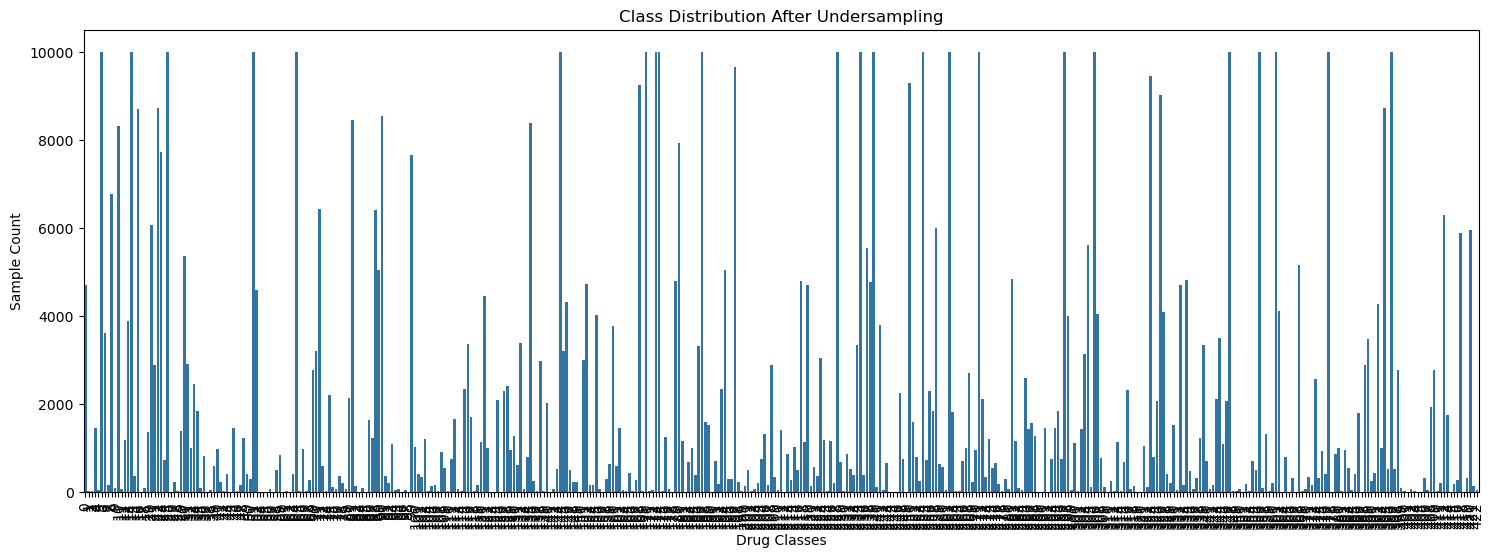

In [942]:
undersampled_distribution = meps_data['Drug'].value_counts().reset_index()
undersampled_distribution.columns = ['Drug', 'Count']

# Plot class distribution after undersampling
plt.figure(figsize=(18, 6))
sns.barplot(x=undersampled_distribution['Drug'], y=undersampled_distribution['Count'])
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.xlabel("Drug Classes")
plt.ylabel("Sample Count")
plt.title("Class Distribution After Undersampling")
plt.show()

In [943]:
class_counts = meps_data['Drug'].value_counts()
rare_classes = class_counts[class_counts <= 100].index
rare_records = meps_data[meps_data['Drug'].isin(rare_classes)]

file_path = "rare_drug_records.csv"
rare_records.to_csv(file_path, index=False)
print(f"Saved rare drug records (count <=100) to '{file_path}'.")

Saved rare drug records (count <=100) to 'rare_drug_records.csv'.


In [944]:
filtered_data = meps_data[~meps_data['Drug'].isin(rare_classes)]

X = filtered_data.drop(columns=['Drug'])
y = filtered_data['Drug']

# # Step 3: Set k_neighbors to 1
# k_neighbors = 10 # Set k_neighbors to 1 to avoid random variability

# # Step 4: Apply SMOTE with k_neighbors = 1
# smote = SMOTE(sampling_strategy='minority', random_state=42, k_neighbors=k_neighbors)
# X_resampled, y_resampled = smote.fit_resample(X, y)

# # Step 5: Convert back to DataFrame and merge rare classes
# X_resampled = pd.DataFrame(X_resampled, columns=X.columns)
# y_resampled = pd.Series(y_resampled, name='Drug')

# balanced_meps_data = X_resampled.copy()
# balanced_meps_data['Drug'] = y_resampled

sample_size = 500000

# Stratified Sampling to maintain class balance
meps_data, _ = train_test_split(filtered_data, 
                                   train_size=sample_size, 
                                   stratify=filtered_data['Drug'], 
                                   random_state=42)

# meps_data = pd.concat([meps_sampled_data, rare_records], ignore_index=True)

class_distribution = meps_data['Drug'].value_counts().reset_index()
class_distribution.columns = ['Drug', 'Count']
class_distribution.to_csv("drug_class_distribution_after_smote.csv", index=False)

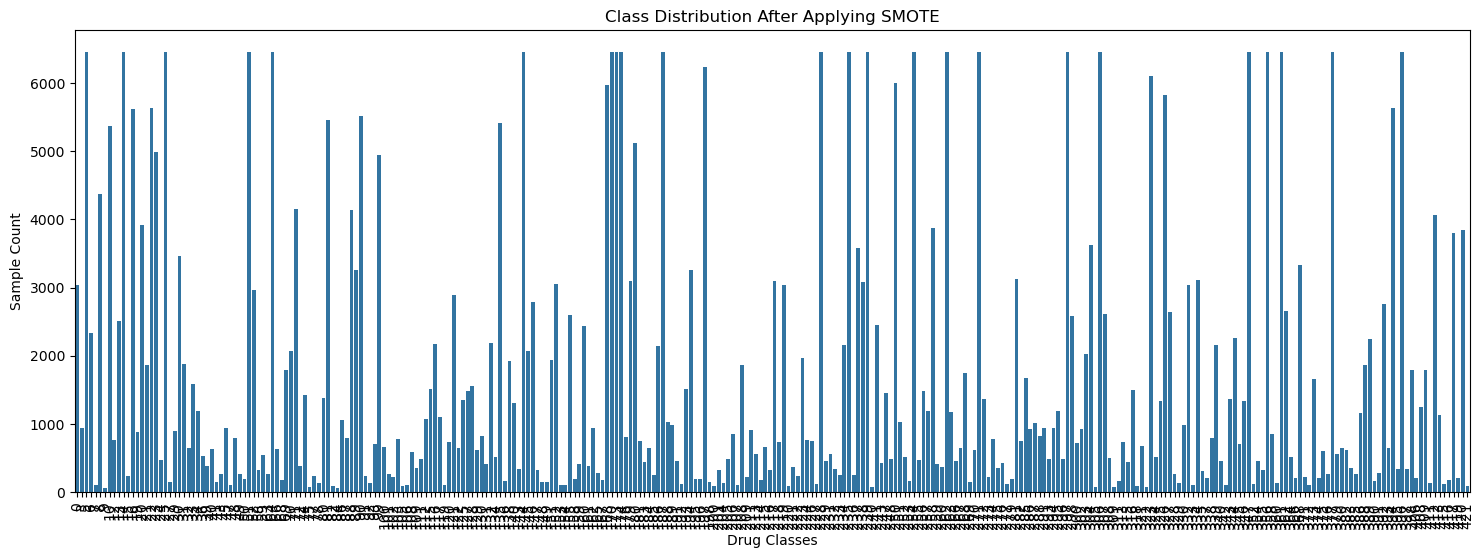

In [945]:
class_distribution = meps_data['Drug'].value_counts().reset_index()
class_distribution.columns = ['Drug', 'Count']

plt.figure(figsize=(18, 6))
sns.barplot(x=class_distribution['Drug'], y=class_distribution['Count'])
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.xlabel("Drug Classes")
plt.ylabel("Sample Count")
plt.title("Class Distribution After Applying SMOTE")
plt.show()

So as we saw the imbalance in dataset, 
we have classes with high count and classes with very low count
so applied a combination of under sampling + smote
first apllied under sampling with minimum count of 500
then removed rare classes with count less than 5
and applied smote and merged rare classes back

Now that are data is sampled applied a statified sampling technique to pull out a balanced sample

As step - 1 apply the model on all the featues

In [946]:
train_meps_data = meps_data[meps_data['Year'] < 2022]  # Training: Years 2012-2021
val_meps_data = meps_data[meps_data['Year'] == 2022]   # Validation: Year 2022

print("Training Data Shape:", train_meps_data.shape)
print("Validation Data Shape:", val_meps_data.shape)

Training Data Shape: (418495, 18)
Validation Data Shape: (81505, 18)


In [947]:
X_train = train_meps_data.drop(columns=['Drug'])
y_train = train_meps_data['Drug']

X_val = val_meps_data.drop(columns=['Drug'])
y_val = val_meps_data['Drug']

dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_val)

accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(classification_report(y_val, y_pred))

Accuracy: 0.4141
Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.46      0.46       412
           3       0.65      0.46      0.54       204
           5       1.00      0.99      0.99      1134
           6       0.99      0.97      0.98       376
           7       0.00      0.00      0.00         0
           8       0.58      0.55      0.57       835
          10       0.62      0.54      0.58       767
          12       0.29      0.57      0.38        90
          13       0.07      0.06      0.06       435
          14       0.15      0.19      0.17      1160
          15       0.81      1.00      0.89        42
          16       0.73      0.70      0.71       853
          19       0.36      0.44      0.40       157
          20       0.70      0.49      0.58      1106
          21       0.19      0.13      0.16       345
          22       0.95      0.96      0.96       995
          23       0.38      0.34      0.

/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

So, Baseline decision tree model is applied and got an accuracy of 0.38% with sampled data

Checking feature importance

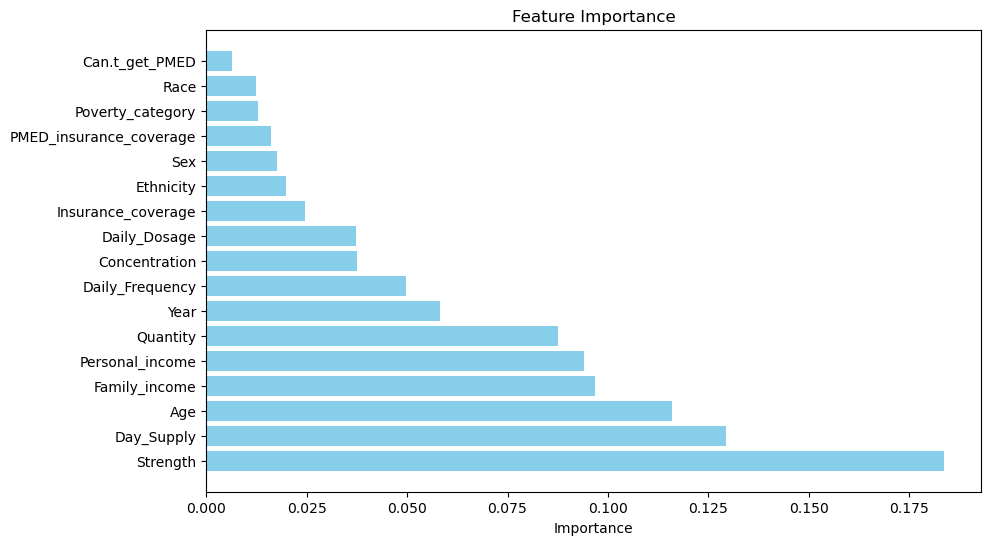

                    Feature  Importance
1                  Strength    0.183659
2                Day_Supply    0.129248
6                       Age    0.116017
11            Family_income    0.096824
10          Personal_income    0.094090
0                  Quantity    0.087637
5                      Year    0.058142
3           Daily_Frequency    0.049732
16            Concentration    0.037596
4              Daily_Dosage    0.037244
14       Insurance_coverage    0.024492
8                 Ethnicity    0.019875
7                       Sex    0.017637
15  PMED_insurance_coverage    0.016106
12         Poverty_category    0.012960
9                      Race    0.012309
13           Can.t_get_PMED    0.006432


In [948]:
importances = dt_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.show()
print(feature_importance_df)

below code loops over 6 least important features and check the model performace

In [949]:
unimportant_features = ['Can.t_get_PMED', 'Race', 'PMED_insurance_coverage', 
                        'Poverty_category', 'Ethnicity', 'Sex']

# Function to train and evaluate the decision tree model
def evaluate_model(X_train, y_train, X_val, y_val, features_to_drop):
    X_train_reduced = X_train.drop(columns=features_to_drop)
    X_val_reduced = X_val.drop(columns=features_to_drop)
    
    dt_model_reduced = DecisionTreeClassifier(random_state=42, class_weight='balanced')
    dt_model_reduced.fit(X_train_reduced, y_train)
    
    y_pred_reduced = dt_model_reduced.predict(X_val_reduced)
    
    accuracy_reduced = accuracy_score(y_val, y_pred_reduced)
    return accuracy_reduced, classification_report(y_val, y_pred_reduced)

# Loop through dropping features one by one from the bottom
for i in range(1, len(unimportant_features)+1):
    features_to_drop = unimportant_features[-i:]  # Drop the least important 'i' features
    
    # Evaluate model after dropping features
    accuracy_reduced, class_report = evaluate_model(X_train, y_train, X_val, y_val, features_to_drop)
    
    print(f"After dropping {i} features ({', '.join(features_to_drop)}):")
    print(f"Accuracy: {accuracy_reduced:.4f}")
    print("Classification Report:")
    print(class_report)
    print("-" * 50)  # Separator for readability

/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

After dropping 1 features (Sex):
Accuracy: 0.4025
Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.50      0.49       412
           3       0.54      0.48      0.51       204
           5       0.99      0.99      0.99      1134
           6       0.98      0.97      0.98       376
           7       0.00      0.00      0.00         0
           8       0.52      0.48      0.50       835
          10       0.58      0.48      0.53       767
          12       0.25      0.43      0.32        90
          13       0.07      0.08      0.08       435
          14       0.15      0.18      0.16      1160
          15       0.81      1.00      0.89        42
          16       0.71      0.68      0.69       853
          19       0.31      0.25      0.27       157
          20       0.67      0.42      0.52      1106
          21       0.21      0.12      0.15       345
          22       0.95      0.96      0.95       995
        

/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

After dropping 2 features (Ethnicity, Sex):
Accuracy: 0.4034
Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.55      0.54       412
           3       0.53      0.46      0.49       204
           5       0.99      0.99      0.99      1134
           6       0.98      0.97      0.98       376
           7       0.00      0.00      0.00         0
           8       0.49      0.46      0.47       835
          10       0.59      0.53      0.56       767
          12       0.21      0.43      0.28        90
          13       0.05      0.06      0.06       435
          14       0.14      0.17      0.15      1160
          15       1.00      1.00      1.00        42
          16       0.73      0.70      0.71       853
          19       0.30      0.22      0.25       157
          20       0.69      0.40      0.51      1106
          21       0.31      0.14      0.19       345
          22       0.95      0.96      0.96       9

/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

...

/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior

After dropping 4 features (PMED_insurance_coverage, Poverty_category, Ethnicity, Sex):
Accuracy: 0.4067
Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.57      0.55       412
           3       0.58      0.47      0.52       204
           5       1.00      0.99      1.00      1134
           6       0.99      0.97      0.98       376
           7       0.00      0.00      0.00         0
           8       0.49      0.46      0.47       835
          10       0.58      0.55      0.56       767
          12       0.17      0.28      0.21        90
          13       0.05      0.05      0.05       435
          14       0.15      0.19      0.17      1160
          15       0.81      1.00      0.89        42
          16       0.72      0.67      0.69       853
          19       0.26      0.23      0.25       157
          20       0.68      0.44      0.53      1106
          21       0.22      0.12      0.15       345
        

/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior

After dropping 5 features (Race, PMED_insurance_coverage, Poverty_category, Ethnicity, Sex):
Accuracy: 0.4035
Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.62      0.59       412
           3       0.55      0.43      0.48       204
           5       0.99      0.99      0.99      1134
           6       0.99      0.97      0.98       376
           7       0.00      0.00      0.00         0
           8       0.50      0.45      0.47       835
           9       0.00      0.00      0.00         0
          10       0.55      0.48      0.52       767
          12       0.12      0.26      0.16        90
          13       0.03      0.03      0.03       435
          14       0.13      0.17      0.15      1160
          15       0.81      1.00      0.89        42
          16       0.73      0.69      0.71       853
          19       0.28      0.25      0.26       157
          20       0.72      0.45      0.55      1106
  

/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

There is no much change in accuracy after dropping unimportant columns

Hyper param tuning

In [950]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
    'max_depth': [None, 3, 5, 10, 20], 
    'min_samples_split': [2, 5, 10],  
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2'], 
    'criterion': ['gini', 'entropy'], 
}

grid_search = GridSearchCV(estimator=dt_model, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)
print("Best Hyperparameters from GridSearchCV:")
print(grid_search.best_params_)
best_dt_model = grid_search.best_estimator_
y_pred = best_dt_model.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy with Best Hyperparameters: {accuracy:.4f}")

# Print the classification report
print("Classification Report:")
print(classification_report(y_val, y_pred))

Fitting 5 folds for each of 270 candidates, totalling 1350 fits


/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Hyperparameters from GridSearchCV:
{'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy with Best Hyperparameters: 0.4209
Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.58      0.48       412
           3       0.64      0.56      0.60       204
           5       0.99      0.99      0.99      1134
           6       1.00      0.98      0.99       376
           8       0.61      0.57      0.59       835
           9       0.00      0.00      0.00         0
          10       0.49      0.44      0.46       767
          12       0.29      0.41      0.34        90
          13       0.08      0.08      0.08       435
          14       0.16      0.19      0.18      1160
          15       1.00      1.00      1.00        42
          16       0.74      0.72      0.73       853
          19       0.32      0.29      0.30       157
          20       0.66 

/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akhilaannireddy/Projects/sewer_project/sewerenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior

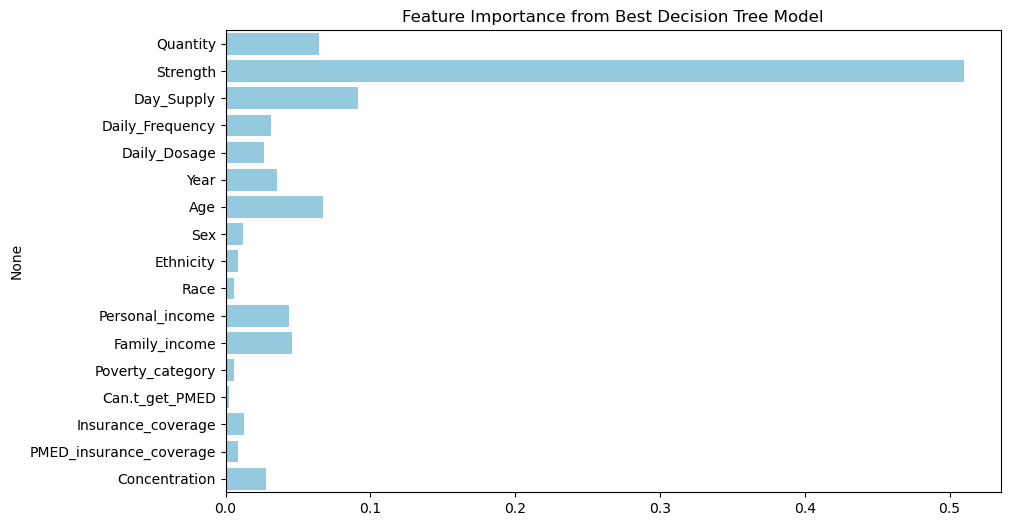

In [951]:
feature_importances = best_dt_model.feature_importances_
feature_names = X_train.columns
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_names, color='skyblue')
plt.title("Feature Importance from Best Decision Tree Model")
plt.show()